### **[Boxplots Are Hiding Your Data. Here’s a Simple Fix](https://andymcdonaldgeo.medium.com/boxplots-are-hiding-your-data-heres-a-simple-fix-d37947f31068)**

> *How overlaying raw data points reveals what your summary statistics quietly discard*

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_style('whitegrid')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

%autosave 15

Autosaving every 15 seconds


In [2]:

aldwick = np.random.normal(0.22, 0.04, 80)
brentford = np.concatenate([
    np.random.normal(0.12, 0.015, 30),
    np.random.normal(0.19, 0.015, 30)
])
castleton = np.concatenate([
    np.random.normal(0.075, 0.012, 45),
    np.random.normal(0.13, 0.01, 5)
])
data = pd.DataFrame({
    'Formation': (
        ['Aldwick'] * len(aldwick) +
        ['Brentford'] * len(brentford) +
        ['Castleton'] * len(castleton)
    ),
    'Porosity': np.concatenate([aldwick, brentford, castleton])
})
data['Porosity'] = data['Porosity'].clip(0, 0.35)

display(data)

,Formation,Porosity
0,Aldwick,0.240
1,Aldwick,0.214
2,Aldwick,0.246
3,Aldwick,0.281
4,Aldwick,0.211
5,Aldwick,0.211
6,Aldwick,0.283
7,Aldwick,0.251
8,Aldwick,0.201
9,Aldwick,0.242


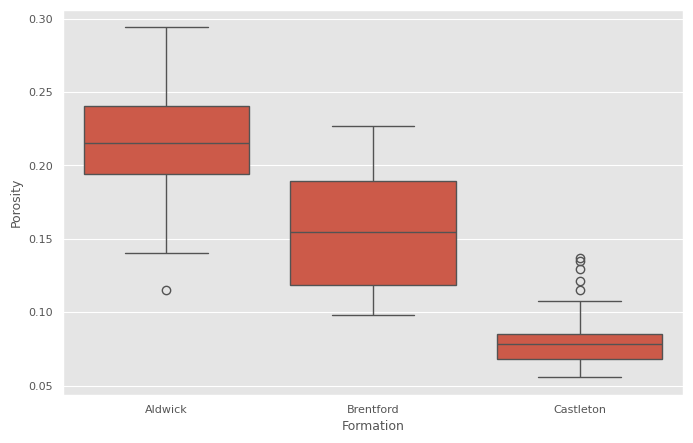

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x='Formation', y='Porosity', ax=ax)
plt.show()

#### **Overlay the Raw Data Points**

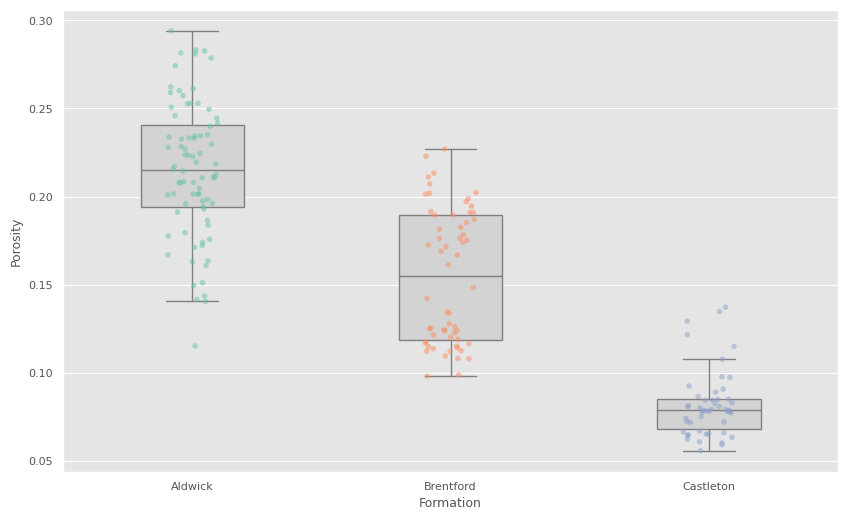

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
  data=data,
  x='Formation',
  y='Porosity',
  ax=ax,
  width=0.4,
  color='lightgray',
  fliersize=0
)
sns.stripplot(
  data=data,
  x='Formation',
  y='Porosity',
  hue='Formation',
  legend=False,
  ax=ax,
  jitter=True,
  size=4,
  alpha=0.5,
  palette='Set2'
)
plt.show()

#### **Reduce Visual Clutter**

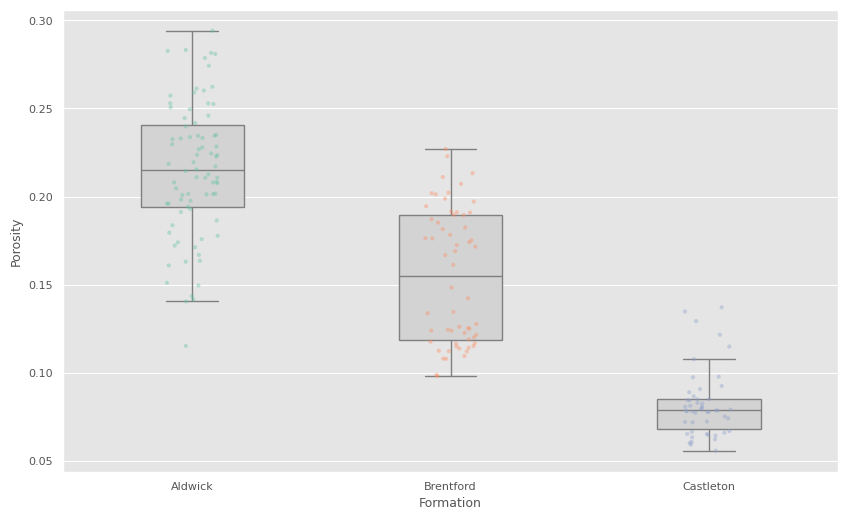

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
  data=data,
  x='Formation',
  y='Porosity',
  ax=ax,
  width=0.4,
  color='lightgray',
  fliersize=0
)
sns.stripplot(
  data=data,
  x='Formation',
  y='Porosity',
  hue='Formation',
  legend=False,
  ax=ax,
  jitter=True,
  size=3,
  alpha=0.4,
  palette='Set2'
)
plt.show()

#### **Add Group Means**

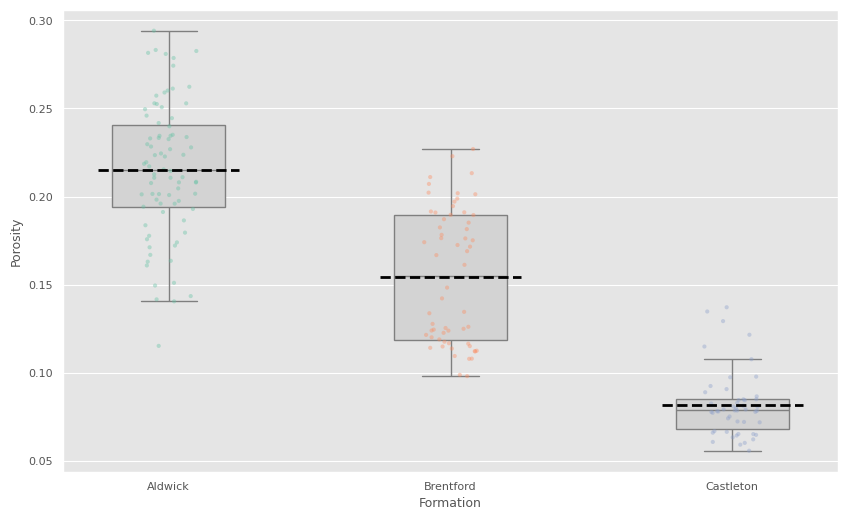

In [6]:
formations = ['Aldwick', 'Brentford', 'Castleton']

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
  data=data,
  x='Formation',
  y='Porosity',
  ax=ax,
  width=0.4,
  color='lightgray',
  fliersize=0
)
sns.stripplot(
  data=data,
  x='Formation',
  y='Porosity',
  hue='Formation',
  legend=False,
  ax=ax,
  jitter=True,
  size=3,
  alpha=0.4,
  palette='Set2'
)
for i, formation in enumerate(formations):
  mean_val = data.loc[data['Formation'] == formation, 'Porosity'].mean()
  ax.hlines(
    mean_val,
    i - 0.25, i + 0.25,
    colors='black',
    linewidths=2,
    linestyles='--',
    zorder=5
  )
plt.show()

#### **Final Polish**

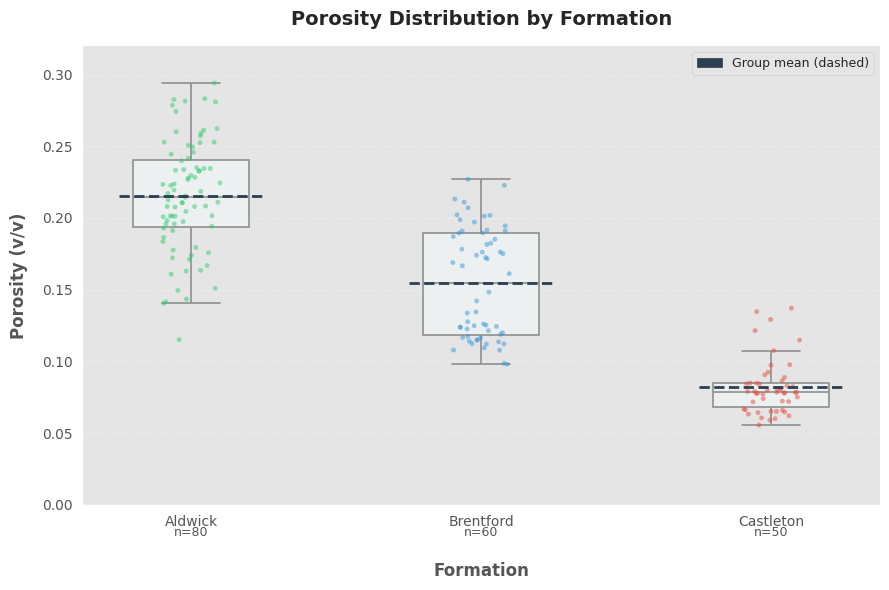

In [7]:
formation_colours = {
  'Aldwick': '#2ecc71',
  'Brentford': '#3498db',
  'Castleton': '#e74c3c'
}

fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
sns.boxplot(
  data=data,
  x='Formation',
  y='Porosity',
  ax=ax,
  width=0.4,
  color='#ecf0f1',
  fliersize=0,
  linewidth=1.2
)
sns.stripplot(
  data=data,
  x='Formation',
  y='Porosity',
  hue='Formation',
  legend=False,
  ax=ax,
  jitter=True,
  size=3.5,
  alpha=0.5,
  palette=list(formation_colours.values())
)
for i, formation in enumerate(formations):
  mean_val = data.loc[data['Formation'] == formation, 'Porosity'].mean()
  ax.hlines(
    mean_val,
    i - 0.25, i + 0.25,
    colors='#2c3e50',
    linewidths=2,
    linestyles='--',
    zorder=5
  )

  n = len(data.loc[data['Formation'] == formation])
  ax.text(
    i, -0.015, f'n={n}',
    ha='center', va='top',
    fontsize=9, color='#555555'
  )
ax.set_xlabel('Formation', fontsize=12, fontweight='bold', labelpad=24)
ax.set_ylabel('Porosity (v/v)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Porosity Distribution by Formation', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.tick_params(axis='both', labelsize=10)
ax.set_ylim(0, 0.32)
mean_patch = mpatches.Patch(color='#2c3e50', label='Group mean (dashed)')
ax.legend(handles=[mean_patch], fontsize=9, framealpha=0.9)
plt.tight_layout()
if not IN_COLAB:
  plt.savefig('porosity_overlay.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()